In [65]:
import numpy as np
import pandas as pd
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from itertools import combinations

ML (Machine Learning)

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_Na = pd.read_csv('C:/Users/OJH/OneDrive/SKKU/연구자료/Catalyst AI/Database/Na_Cat_preprocess.csv')
# or
# filtered_Na = pd.read_csv('C:\\Users\\OJH\\OneDrive\\SKKU\\연구자료\\Catalyst AI\\Database\\Na_Cat_preprocess.csv')


In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

column_names = filtered_Na.columns.tolist()
column_names

input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]
output_column = 'Y(C2), %'

input_columns

from sklearn.model_selection import train_test_split

X = filtered_Na[input_columns]
y = filtered_Na[output_column]

In [68]:
filtered_data = filtered_Na[(filtered_Na['Na_C_mol%'] >= 2.1) & (filtered_Na['Na_C_mol%'] <= 60)]

proportion_filtered = len(filtered_data) / len(filtered_Na['Na_C_mol%']) * 100

train_data = filtered_data
test_data = filtered_Na.drop(filtered_data.index)

print(f"Proportion of data where 'Na_C_mol%' is between 10 and 70: {proportion_filtered}%")
print(f"Shape of train_data: {train_data.shape}")
print(f"Shape of test_data: {test_data.shape}")

Proportion of data where 'Na_C_mol%' is between 10 and 70: 70.49345417925478%
Shape of train_data: (700, 30)
Shape of test_data: (293, 30)


In [69]:
# input_columns: The list of input features you want to consider for your model
input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'S(COx), %', 'Y(C2), %']]

# output_column: The output you are trying to predict
output_column = 'Y(C2), %'

# Define X_train, y_train based on the train_data DataFrame
X_train = train_data[input_columns]
y_train = train_data[output_column]

# Define X_test, y_test based on the test_data DataFrame
X_test = test_data[input_columns]
y_test = test_data[output_column]

In [70]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the StandardScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both the training and test data
Na_train_scaled = scaler.fit_transform(filtered_Na[input_columns])
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_1 = MinMaxScaler()

# Reshape the output_column to be 2D
output_scaled = scaler_1.fit_transform(filtered_Na[output_column].values.reshape(-1, 1))

# Reshape the y_train and y_test to be 2D
y_train_scaled = scaler_1.transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_1.transform(y_test.values.reshape(-1, 1))

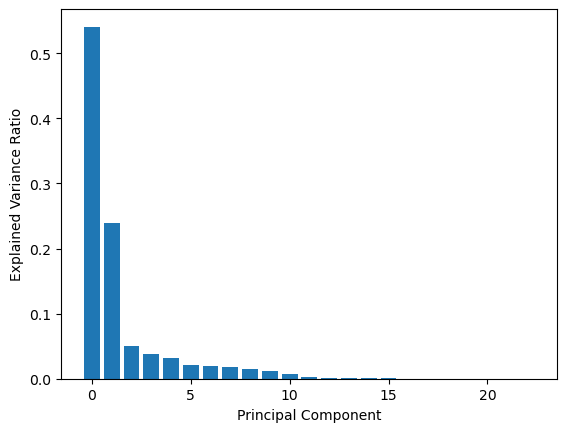

6


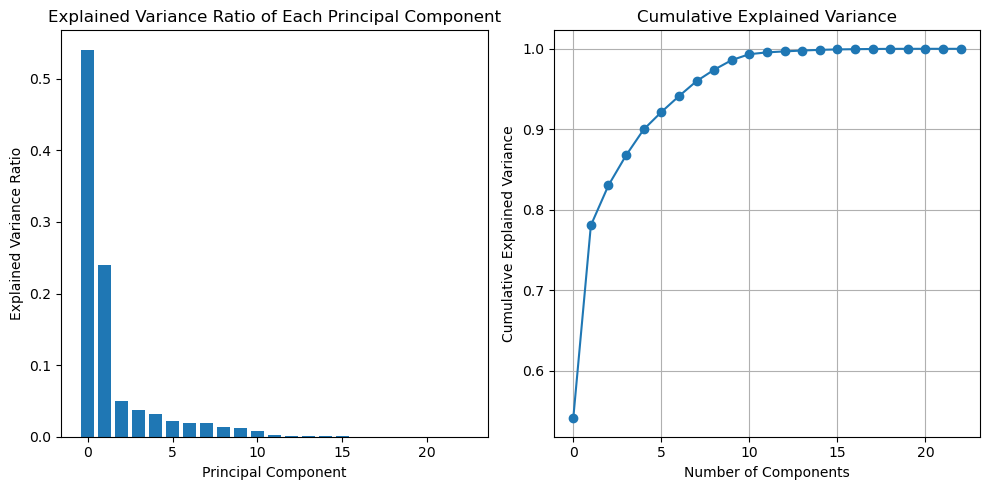

In [71]:
from sklearn.decomposition import PCA

# 데이터를 중앙에 맞춤 (선택 사항, PCA 내부적으로 수행됨)
# X_train_centered = X_train - np.mean(X_train, axis=0)
# X_test_centered = X_test - np.mean(X_test, axis=0)

# PCA 객체 생성
pca = PCA()

# PCA를 학습 데이터에 적합시킴
pca.fit(filtered_Na[input_columns])

# 설명된 분산의 비율을 확인
explained_var_ratio = pca.explained_variance_ratio_

# 설명된 분산의 비율을 시각화
plt.bar(range(len(explained_var_ratio)), explained_var_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

# 설명된 분산이 95% 이상이 되는 주성분 개수 선택
n_components = np.where(np.cumsum(explained_var_ratio) >= 0.90)[0][0] + 1

print(n_components)

# 선택된 주성분 개수로 PCA 다시 수행
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 설명된 분산의 누적 비율
cumulative_explained_var = np.cumsum(explained_var_ratio)

# 개별 주성분에 대한 설명된 분산 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(len(explained_var_ratio)), explained_var_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Each Principal Component')

# 누적 설명된 분산 시각화
plt.subplot(1, 2, 2)
plt.plot(range(len(cumulative_explained_var)), cumulative_explained_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True)

plt.tight_layout()
plt.show()

In [72]:
# 가장 좋은 RMSE와 R2를 주는 테스트 데이터 점을 추출
best_test_point_r2 = 171
best_test_point_rmse = 171

best_test_point_for_rmse = X_test_pca[best_test_point_rmse, :]
best_test_point_for_r2 = X_test_pca[best_test_point_r2, :]

print(f"Best test point for RMSE: {best_test_point_for_rmse}")
print(f"Best test point for R2: {best_test_point_for_r2}")

Best test point for RMSE: [ 0.09224516 -0.01809502 -0.07144999 -0.04530387 -0.01145415  0.07443937]
Best test point for R2: [ 0.09224516 -0.01809502 -0.07144999 -0.04530387 -0.01145415  0.07443937]


In [73]:
print(best_test_point_r2)
print(best_test_point_r2)

171
171


In [74]:
def optimize_mlp(learning_rate, hidden_units_1, hidden_units_2):
    model = Sequential()
    model.add(Dense(int(hidden_units_1), activation='relu', input_shape=(X_train_pca.shape[1],)))
    model.add(Dense(int(hidden_units_2), activation='relu'))
    model.add(Dense(1, activation='relu'))
    
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    
    model.fit(X_train_pca, y_train_scaled, epochs=100, batch_size=16, verbose=0)
    
    predictions = model.predict(X_train_pca).flatten()
    
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

In [75]:
X_train_original = X_train_pca.copy()
y_train_original = y_train_scaled.copy()
X_test_original = X_test_pca.copy()
y_test_original = y_test_scaled.copy()
    
original_test_length = len(X_test_original)

X_train_original = pd.DataFrame(X_train_original)
X_test_original = pd.DataFrame(X_test_original)
y_train_original = pd.DataFrame(y_train_original)
y_test_original = pd.DataFrame(y_test_original)

X_train_expanded = pd.concat([X_train_original, X_test_original.iloc[[best_test_point_rmse]]], ignore_index=True)
y_train_expanded = pd.concat([y_train_original, y_test_original.iloc[[best_test_point_rmse]]], ignore_index=True)

X_test_reduced = X_test_original.drop(X_test_original.index[best_test_point_rmse])
y_test_reduced = y_test_original.drop(y_test_original.index[best_test_point_rmse])

print(X_train_expanded.shape)
print(X_test_reduced.shape)
        
# Re-optimize hyperparameters with Bayesian Optimization
pbounds = {'learning_rate': (0.0001, 0.01), 'hidden_units_1': (10, 100), 'hidden_units_2': (10, 100)}
optimizer = BayesianOptimization(f=optimize_mlp, pbounds=pbounds, random_state=42)
optimizer.maximize(init_points=20, n_iter=40)
        
best_params = optimizer.max['params']
        
model = Sequential()
model.add(Dense(int(best_params['hidden_units_1']), activation='relu', input_shape=(6,)))
model.add(Dense(int(best_params['hidden_units_2']), activation='relu'))
model.add(Dense(1, activation='relu'))
        
optimizer = Adam(learning_rate=best_params['learning_rate'])
        
model.compile(loss='mean_squared_error', optimizer=optimizer)
model.fit(X_train_expanded, y_train_expanded, epochs=100, batch_size=16, verbose=0)
        
# Get new predictions for the test set
predictions_best = model.predict(X_test_reduced).flatten()

(701, 6)
(292, 6)
|   iter    |  target   | hidden... | hidden... | learni... |
-------------------------------------------------------------
22/22 [==============================] - 0s 380us/step
| 1         | -0.1533   | 43.71     | 95.56     | 0.007347  |
22/22 [==============================] - 0s 417us/step
| 2         | -0.1581   | 63.88     | 24.04     | 0.001644  |
22/22 [==============================] - 0s 394us/step
| 3         | -0.1599   | 15.23     | 87.96     | 0.006051  |
22/22 [==============================] - 0s 364us/step
| 4         | -0.1633   | 73.73     | 11.85     | 0.009702  |
22/22 [==============================] - 0s 411us/step
| 5         | -0.1544   | 84.92     | 29.11     | 0.0019    |
22/22 [==============================] - 0s 436us/step
| 6         | -0.1536   | 26.51     | 37.38     | 0.005295  |
22/22 [==============================] - 0s 427us/step
| 7         | -0.1625   | 48.88     | 36.21     | 0.006157  |
22/22 [==============================] 

In [ ]:
# 레이어 가중치 분석

weights = model.layers[0].get_weights()[0]
print('First layer weights shape:', weights.shape)

First layer weights shape: (6, 18)


In [ ]:
print("Shape of X_train_expanded:", X_train_expanded.shape)
print("Shape of y_train_expanded:", y_train_expanded.shape)
# Pandas DataFrame을 Numpy 배열로 변환 후 reshape
X_train_expanded = X_train_expanded.to_numpy().reshape(-1, 6)
y_train_expanded = y_train_expanded.to_numpy().reshape(-1, 1)
X_test_reduced = X_test_reduced.to_numpy().reshape(-1, 6)
y_test_reduced = y_test_reduced.to_numpy().reshape(-1, 1)

Shape of X_train_expanded: (701, 6)
Shape of y_train_expanded: (701, 1)


In [ ]:
# LIME (Locally Interpretable Model-agnostic Explanations)
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(X_train_expanded, training_labels=y_train_expanded.flatten(), feautre_names=input_columns, mode='regression')
exp = explainer.explain_instance(X_test_reduced[291], model.predict)
exp.show_in_notebook()

157/157 [==============================] - 0s 601us/step


  1/200 [..............................] - ETA: 2s

22/22 [==============================] - 0s 359us/step


ExactExplainer explainer:  23%|██▎       | 66/292 [00:00<?, ?it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  23%|██▎       | 68/292 [00:10<00:17, 12.99it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  24%|██▍       | 70/292 [00:10<00:27,  8.11it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  24%|██▍       | 71/292 [00:10<00:29,  7.51it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  25%|██▍       | 72/292 [00:10<00:30,  7.21it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  25%|██▌       | 73/292 [00:11<00:31,  6.88it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  25%|██▌       | 74/292 [00:11<00:32,  6.80it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  26%|██▌       | 75/292 [00:11<00:32,  6.65it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  26%|██▌       | 76/292 [00:11<00:32,  6.58it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  26%|██▋       | 77/292 [00:11<00:32,  6.53it/s]

22/22 [==============================] - 0s 500us/step


ExactExplainer explainer:  27%|██▋       | 78/292 [00:11<00:33,  6.38it/s]

22/22 [==============================] - 0s 407us/step


ExactExplainer explainer:  27%|██▋       | 79/292 [00:12<00:33,  6.37it/s]

22/22 [==============================] - 0s 354us/step


ExactExplainer explainer:  27%|██▋       | 80/292 [00:12<00:33,  6.38it/s]

22/22 [==============================] - 0s 386us/step


ExactExplainer explainer:  28%|██▊       | 81/292 [00:12<00:33,  6.38it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  28%|██▊       | 82/292 [00:12<00:33,  6.35it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  28%|██▊       | 83/292 [00:12<00:33,  6.22it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  29%|██▉       | 84/292 [00:12<00:33,  6.29it/s]

22/22 [==============================] - 0s 383us/step


ExactExplainer explainer:  29%|██▉       | 85/292 [00:12<00:32,  6.31it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  29%|██▉       | 86/292 [00:13<00:32,  6.33it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  30%|██▉       | 87/292 [00:13<00:32,  6.36it/s]

22/22 [==============================] - 0s 324us/step


ExactExplainer explainer:  30%|███       | 88/292 [00:13<00:32,  6.24it/s]

22/22 [==============================] - 0s 328us/step


ExactExplainer explainer:  30%|███       | 89/292 [00:13<00:32,  6.30it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  31%|███       | 90/292 [00:13<00:31,  6.34it/s]

22/22 [==============================] - 0s 358us/step


ExactExplainer explainer:  31%|███       | 91/292 [00:13<00:31,  6.34it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  32%|███▏      | 92/292 [00:14<00:31,  6.38it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  32%|███▏      | 93/292 [00:14<00:31,  6.36it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  32%|███▏      | 94/292 [00:14<00:31,  6.37it/s]

22/22 [==============================] - 0s 570us/step


ExactExplainer explainer:  33%|███▎      | 95/292 [00:14<00:31,  6.28it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  33%|███▎      | 96/292 [00:14<00:31,  6.28it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  33%|███▎      | 97/292 [00:14<00:30,  6.36it/s]

22/22 [==============================] - 0s 393us/step


ExactExplainer explainer:  34%|███▎      | 98/292 [00:15<00:30,  6.33it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  34%|███▍      | 99/292 [00:15<00:30,  6.35it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  34%|███▍      | 100/292 [00:15<00:30,  6.30it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  35%|███▍      | 101/292 [00:15<00:30,  6.36it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  35%|███▍      | 102/292 [00:15<00:29,  6.39it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  35%|███▌      | 103/292 [00:15<00:29,  6.32it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  36%|███▌      | 104/292 [00:15<00:29,  6.37it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  36%|███▌      | 105/292 [00:16<00:29,  6.41it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  36%|███▋      | 106/292 [00:16<00:29,  6.32it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  37%|███▋      | 107/292 [00:16<00:29,  6.37it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  37%|███▋      | 108/292 [00:16<00:28,  6.35it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  37%|███▋      | 109/292 [00:16<00:28,  6.41it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  38%|███▊      | 110/292 [00:16<00:28,  6.43it/s]

22/22 [==============================] - 0s 336us/step


ExactExplainer explainer:  38%|███▊      | 111/292 [00:17<00:28,  6.39it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  38%|███▊      | 112/292 [00:17<00:28,  6.41it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  39%|███▊      | 113/292 [00:17<00:28,  6.31it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  39%|███▉      | 114/292 [00:17<00:27,  6.40it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  39%|███▉      | 115/292 [00:17<00:27,  6.42it/s]

22/22 [==============================] - 0s 285us/step


ExactExplainer explainer:  40%|███▉      | 116/292 [00:17<00:27,  6.46it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  40%|████      | 117/292 [00:18<00:26,  6.54it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  40%|████      | 118/292 [00:18<00:26,  6.44it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  41%|████      | 119/292 [00:18<00:26,  6.47it/s]

22/22 [==============================] - 0s 383us/step


ExactExplainer explainer:  41%|████      | 120/292 [00:18<00:26,  6.44it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  41%|████▏     | 121/292 [00:18<00:26,  6.46it/s]

22/22 [==============================] - 0s 336us/step


ExactExplainer explainer:  42%|████▏     | 122/292 [00:18<00:26,  6.49it/s]

22/22 [==============================] - 0s 288us/step


ExactExplainer explainer:  42%|████▏     | 123/292 [00:18<00:26,  6.43it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  42%|████▏     | 124/292 [00:19<00:25,  6.52it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  43%|████▎     | 125/292 [00:19<00:25,  6.55it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  43%|████▎     | 126/292 [00:19<00:25,  6.57it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  43%|████▎     | 127/292 [00:19<00:25,  6.53it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  44%|████▍     | 128/292 [00:19<00:25,  6.33it/s]

22/22 [==============================] - 0s 447us/step


ExactExplainer explainer:  44%|████▍     | 129/292 [00:19<00:25,  6.30it/s]

22/22 [==============================] - 0s 335us/step


ExactExplainer explainer:  45%|████▍     | 130/292 [00:20<00:25,  6.40it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  45%|████▍     | 131/292 [00:20<00:24,  6.45it/s]

22/22 [==============================] - 0s 363us/step


ExactExplainer explainer:  45%|████▌     | 132/292 [00:20<00:24,  6.45it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  46%|████▌     | 133/292 [00:20<00:24,  6.39it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  46%|████▌     | 134/292 [00:20<00:24,  6.48it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  46%|████▌     | 135/292 [00:20<00:24,  6.54it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  47%|████▋     | 136/292 [00:20<00:23,  6.54it/s]

22/22 [==============================] - 0s 285us/step


ExactExplainer explainer:  47%|████▋     | 137/292 [00:21<00:23,  6.59it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  47%|████▋     | 138/292 [00:21<00:23,  6.48it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  48%|████▊     | 139/292 [00:21<00:23,  6.47it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  48%|████▊     | 140/292 [00:21<00:23,  6.47it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  48%|████▊     | 141/292 [00:21<00:23,  6.43it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  49%|████▊     | 142/292 [00:21<00:23,  6.42it/s]

22/22 [==============================] - 0s 392us/step


ExactExplainer explainer:  49%|████▉     | 143/292 [00:22<00:23,  6.31it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  49%|████▉     | 144/292 [00:22<00:23,  6.30it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  50%|████▉     | 145/292 [00:22<00:23,  6.34it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  50%|█████     | 146/292 [00:22<00:23,  6.31it/s]

22/22 [==============================] - 0s 570us/step


ExactExplainer explainer:  50%|█████     | 147/292 [00:22<00:23,  6.24it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  51%|█████     | 148/292 [00:22<00:23,  6.25it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  51%|█████     | 149/292 [00:22<00:22,  6.25it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  51%|█████▏    | 150/292 [00:23<00:22,  6.21it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  52%|█████▏    | 151/292 [00:23<00:22,  6.31it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  52%|█████▏    | 152/292 [00:23<00:22,  6.29it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  52%|█████▏    | 153/292 [00:23<00:21,  6.37it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  53%|█████▎    | 154/292 [00:23<00:21,  6.34it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  53%|█████▎    | 155/292 [00:23<00:21,  6.29it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  53%|█████▎    | 156/292 [00:24<00:21,  6.30it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  54%|█████▍    | 157/292 [00:24<00:21,  6.32it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  54%|█████▍    | 158/292 [00:24<00:21,  6.34it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  54%|█████▍    | 159/292 [00:24<00:20,  6.37it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  55%|█████▍    | 160/292 [00:24<00:20,  6.30it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  55%|█████▌    | 161/292 [00:24<00:20,  6.33it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  55%|█████▌    | 162/292 [00:25<00:20,  6.41it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  56%|█████▌    | 163/292 [00:25<00:19,  6.45it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  56%|█████▌    | 164/292 [00:25<00:20,  6.32it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  57%|█████▋    | 165/292 [00:25<00:19,  6.42it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  57%|█████▋    | 166/292 [00:25<00:19,  6.41it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  57%|█████▋    | 167/292 [00:25<00:19,  6.48it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  58%|█████▊    | 168/292 [00:25<00:19,  6.29it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  58%|█████▊    | 169/292 [00:26<00:19,  6.34it/s]

22/22 [==============================] - 0s 331us/step


ExactExplainer explainer:  58%|█████▊    | 170/292 [00:26<00:19,  6.31it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  59%|█████▊    | 171/292 [00:26<00:19,  6.18it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  59%|█████▉    | 172/292 [00:26<00:19,  6.28it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  59%|█████▉    | 173/292 [00:26<00:18,  6.29it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  60%|█████▉    | 174/292 [00:26<00:18,  6.24it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  60%|█████▉    | 175/292 [00:27<00:19,  6.14it/s]

22/22 [==============================] - 0s 400us/step


ExactExplainer explainer:  60%|██████    | 176/292 [00:27<00:18,  6.23it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  61%|██████    | 177/292 [00:27<00:18,  6.24it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  61%|██████    | 178/292 [00:27<00:18,  6.31it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  61%|██████▏   | 179/292 [00:27<00:17,  6.35it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  62%|██████▏   | 180/292 [00:27<00:17,  6.31it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  62%|██████▏   | 181/292 [00:28<00:17,  6.34it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  62%|██████▏   | 182/292 [00:28<00:17,  6.37it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  63%|██████▎   | 183/292 [00:28<00:17,  6.38it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  63%|██████▎   | 184/292 [00:28<00:17,  6.20it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  63%|██████▎   | 185/292 [00:28<00:17,  6.27it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  64%|██████▎   | 186/292 [00:28<00:16,  6.37it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  64%|██████▍   | 187/292 [00:29<00:16,  6.41it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  64%|██████▍   | 188/292 [00:29<00:16,  6.40it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  65%|██████▍   | 189/292 [00:29<00:16,  6.34it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  65%|██████▌   | 190/292 [00:29<00:16,  6.31it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  65%|██████▌   | 191/292 [00:29<00:15,  6.33it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  66%|██████▌   | 192/292 [00:29<00:15,  6.35it/s]

22/22 [==============================] - 0s 617us/step


ExactExplainer explainer:  66%|██████▌   | 193/292 [00:29<00:15,  6.23it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  66%|██████▋   | 194/292 [00:30<00:15,  6.31it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  67%|██████▋   | 195/292 [00:30<00:15,  6.39it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  67%|██████▋   | 196/292 [00:30<00:14,  6.43it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  67%|██████▋   | 197/292 [00:30<00:14,  6.46it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  68%|██████▊   | 198/292 [00:30<00:14,  6.31it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  68%|██████▊   | 199/292 [00:30<00:14,  6.33it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  68%|██████▊   | 200/292 [00:31<00:14,  6.35it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  69%|██████▉   | 201/292 [00:31<00:14,  6.36it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  69%|██████▉   | 202/292 [00:31<00:14,  6.35it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  70%|██████▉   | 203/292 [00:31<00:14,  6.23it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  70%|██████▉   | 204/292 [00:31<00:14,  6.23it/s]

22/22 [==============================] - 0s 334us/step


ExactExplainer explainer:  70%|███████   | 205/292 [00:31<00:13,  6.28it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  71%|███████   | 206/292 [00:32<00:13,  6.21it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  71%|███████   | 207/292 [00:32<00:13,  6.24it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  71%|███████   | 208/292 [00:32<00:13,  6.28it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  72%|███████▏  | 209/292 [00:32<00:13,  6.31it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  72%|███████▏  | 210/292 [00:32<00:12,  6.37it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  72%|███████▏  | 211/292 [00:32<00:12,  6.30it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  73%|███████▎  | 212/292 [00:32<00:12,  6.38it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  73%|███████▎  | 213/292 [00:33<00:12,  6.39it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  73%|███████▎  | 214/292 [00:33<00:12,  6.44it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  74%|███████▎  | 215/292 [00:33<00:19,  3.92it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  74%|███████▍  | 216/292 [00:33<00:17,  4.43it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  74%|███████▍  | 217/292 [00:34<00:15,  4.88it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  75%|███████▍  | 218/292 [00:34<00:14,  5.26it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  75%|███████▌  | 219/292 [00:34<00:13,  5.44it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  75%|███████▌  | 220/292 [00:34<00:12,  5.65it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  76%|███████▌  | 221/292 [00:34<00:12,  5.77it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  76%|███████▌  | 222/292 [00:34<00:12,  5.79it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  76%|███████▋  | 223/292 [00:35<00:11,  5.90it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  77%|███████▋  | 224/292 [00:35<00:11,  5.92it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  77%|███████▋  | 225/292 [00:35<00:11,  6.05it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  77%|███████▋  | 226/292 [00:35<00:10,  6.10it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  78%|███████▊  | 227/292 [00:35<00:10,  6.20it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  78%|███████▊  | 228/292 [00:35<00:10,  6.20it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  78%|███████▊  | 229/292 [00:36<00:10,  6.17it/s]

22/22 [==============================] - 0s 309us/step


ExactExplainer explainer:  79%|███████▉  | 230/292 [00:36<00:09,  6.31it/s]

22/22 [==============================] - 0s 301us/step


ExactExplainer explainer:  79%|███████▉  | 231/292 [00:36<00:09,  6.46it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  79%|███████▉  | 232/292 [00:36<00:09,  6.53it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  80%|███████▉  | 233/292 [00:36<00:08,  6.63it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  80%|████████  | 234/292 [00:36<00:08,  6.59it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  80%|████████  | 235/292 [00:36<00:08,  6.50it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  81%|████████  | 236/292 [00:37<00:08,  6.54it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  81%|████████  | 237/292 [00:37<00:08,  6.59it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  82%|████████▏ | 238/292 [00:37<00:08,  6.63it/s]

22/22 [==============================] - 0s 381us/step


ExactExplainer explainer:  82%|████████▏ | 239/292 [00:37<00:08,  6.55it/s]

22/22 [==============================] - 0s 512us/step


ExactExplainer explainer:  82%|████████▏ | 240/292 [00:37<00:07,  6.51it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  83%|████████▎ | 241/292 [00:37<00:07,  6.51it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  83%|████████▎ | 242/292 [00:37<00:07,  6.51it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  83%|████████▎ | 243/292 [00:38<00:07,  6.30it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  84%|████████▎ | 244/292 [00:38<00:07,  6.29it/s]

22/22 [==============================] - 0s 434us/step


ExactExplainer explainer:  84%|████████▍ | 245/292 [00:38<00:07,  6.29it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  84%|████████▍ | 246/292 [00:38<00:07,  6.21it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  85%|████████▍ | 247/292 [00:38<00:07,  6.25it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  85%|████████▍ | 248/292 [00:38<00:07,  6.21it/s]

22/22 [==============================] - 0s 416us/step


ExactExplainer explainer:  85%|████████▌ | 249/292 [00:39<00:06,  6.17it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  86%|████████▌ | 250/292 [00:39<00:06,  6.12it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  86%|████████▌ | 251/292 [00:39<00:06,  6.15it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  86%|████████▋ | 252/292 [00:39<00:06,  6.14it/s]

22/22 [==============================] - 0s 335us/step


ExactExplainer explainer:  87%|████████▋ | 253/292 [00:39<00:06,  6.17it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  87%|████████▋ | 254/292 [00:39<00:06,  6.13it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  87%|████████▋ | 255/292 [00:40<00:05,  6.18it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  88%|████████▊ | 256/292 [00:40<00:05,  6.25it/s]

22/22 [==============================] - 0s 333us/step


ExactExplainer explainer:  88%|████████▊ | 257/292 [00:40<00:05,  6.29it/s]

22/22 [==============================] - 0s 475us/step


ExactExplainer explainer:  88%|████████▊ | 258/292 [00:40<00:05,  6.23it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  89%|████████▊ | 259/292 [00:40<00:05,  6.21it/s]

22/22 [==============================] - 0s 427us/step


ExactExplainer explainer:  89%|████████▉ | 260/292 [00:40<00:05,  6.21it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  89%|████████▉ | 261/292 [00:41<00:05,  6.19it/s]

22/22 [==============================] - 0s 285us/step


ExactExplainer explainer:  90%|████████▉ | 262/292 [00:41<00:04,  6.19it/s]

22/22 [==============================] - 0s 377us/step


ExactExplainer explainer:  90%|█████████ | 263/292 [00:41<00:04,  6.22it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  90%|█████████ | 264/292 [00:41<00:04,  6.24it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  91%|█████████ | 265/292 [00:41<00:04,  6.18it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  91%|█████████ | 266/292 [00:41<00:04,  6.12it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  91%|█████████▏| 267/292 [00:42<00:04,  6.16it/s]

22/22 [==============================] - 0s 475us/step


ExactExplainer explainer:  92%|█████████▏| 268/292 [00:42<00:03,  6.17it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  92%|█████████▏| 269/292 [00:42<00:03,  6.10it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  92%|█████████▏| 270/292 [00:42<00:03,  6.04it/s]

22/22 [==============================] - 0s 449us/step


ExactExplainer explainer:  93%|█████████▎| 271/292 [00:42<00:03,  6.11it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  93%|█████████▎| 272/292 [00:42<00:03,  6.19it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  93%|█████████▎| 273/292 [00:43<00:03,  6.14it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  94%|█████████▍| 274/292 [00:43<00:02,  6.26it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  94%|█████████▍| 275/292 [00:43<00:02,  6.20it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  95%|█████████▍| 276/292 [00:43<00:02,  6.26it/s]

22/22 [==============================] - 0s 365us/step


ExactExplainer explainer:  95%|█████████▍| 277/292 [00:43<00:02,  6.24it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  95%|█████████▌| 278/292 [00:43<00:02,  6.20it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  96%|█████████▌| 279/292 [00:43<00:02,  6.15it/s]

22/22 [==============================] - 0s 285us/step


ExactExplainer explainer:  96%|█████████▌| 280/292 [00:44<00:01,  6.13it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  96%|█████████▌| 281/292 [00:44<00:01,  6.18it/s]

22/22 [==============================] - 0s 369us/step


ExactExplainer explainer:  97%|█████████▋| 282/292 [00:44<00:01,  6.20it/s]

22/22 [==============================] - 0s 333us/step


ExactExplainer explainer:  97%|█████████▋| 283/292 [00:44<00:01,  6.22it/s]

22/22 [==============================] - 0s 334us/step


ExactExplainer explainer:  97%|█████████▋| 284/292 [00:44<00:01,  6.22it/s]

22/22 [==============================] - 0s 285us/step


ExactExplainer explainer:  98%|█████████▊| 285/292 [00:44<00:01,  6.18it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  98%|█████████▊| 286/292 [00:45<00:00,  6.22it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  98%|█████████▊| 287/292 [00:45<00:00,  6.21it/s]

22/22 [==============================] - 0s 380us/step


ExactExplainer explainer:  99%|█████████▊| 288/292 [00:45<00:00,  6.25it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  99%|█████████▉| 289/292 [00:45<00:00,  6.27it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer:  99%|█████████▉| 290/292 [00:45<00:00,  6.15it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer: 100%|█████████▉| 291/292 [00:45<00:00,  6.14it/s]

22/22 [==============================] - 0s 332us/step


ExactExplainer explainer: 100%|██████████| 292/292 [00:46<00:00,  6.27it/s]

22/22 [==============================] - 0s 337us/step


ExactExplainer explainer: 293it [00:46,  4.91it/s]                         


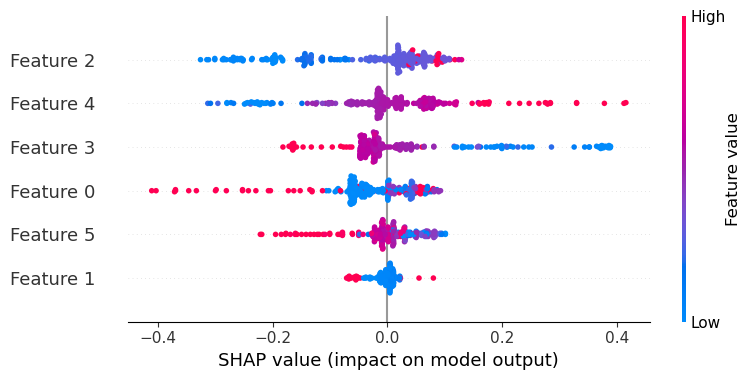

In [ ]:
# SHAP (SHapley Additive exPlanations)
import shap

explainer_shap = shap.Explainer(model.predict, shap.sample(X_train_expanded, 100))
shap_values = explainer_shap(X_test_reduced)  # Notice the change here
shap.summary_plot(shap_values, X_test_reduced)

In [ ]:
shap.initjs()
shap.plots.force(shap_values[0])

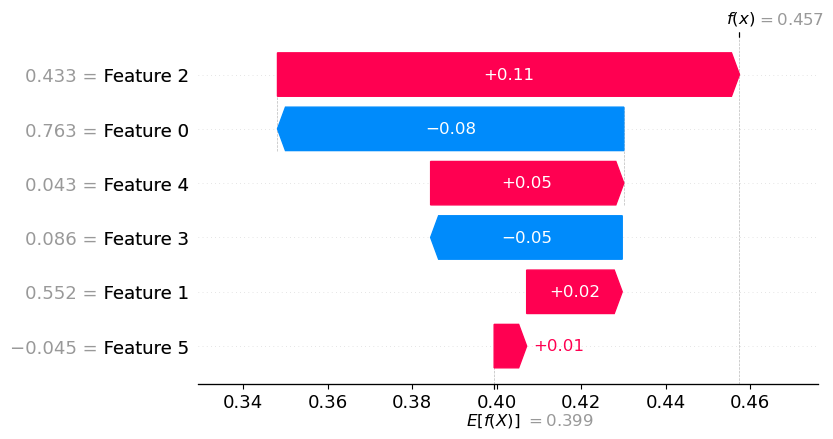

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
components = pca.components_

components_df = pd.DataFrame(components, columns=[f"Feature_{i+1}" for i in range(components.shape[1])])

print(components_df)

   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0   0.038113  -0.222069  -0.037813  -0.014614   0.004340   0.017277   
1   0.120120  -0.601371  -0.044045   0.049463  -0.000372   0.025759   
2   0.157905  -0.577211   0.071091  -0.101865  -0.000099  -0.022865   
3  -0.027495  -0.252462  -0.039333   0.321712  -0.002753   0.023068   
4   0.181211  -0.041191   0.118966  -0.000004   0.001661  -0.001421   
5  -0.045848   0.038790  -0.530621   0.195422  -0.011166  -0.008644   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_14  Feature_15  \
0   0.100608   0.084938   0.147889    0.063947  ...   -0.023995    0.074470   
1   0.088240   0.044884   0.159359    0.199396  ...   -0.029235    0.031597   
2  -0.075159  -0.061254  -0.511289    0.231914  ...    0.013296   -0.077595   
3  -0.187257  -0.219865   0.685829   -0.058084  ...   -0.011310   -0.247025   
4  -0.288861   0.254221   0.066520   -0.110209  ...   -0.000775    0.766698   
5  -0.199730  -0.242908  -0.

In [ ]:
# 원래 특성 이름 가져오기
original_feature_names = filtered_Na[input_columns].columns.tolist()

# PCA 로딩 벡터를 DataFrame으로 변환
components_df = pd.DataFrame(pca.components_, columns=original_feature_names)

# 첫 번째 주성분의 로딩을 내림차순으로 정렬하여 가장 영향력 있는 특성을 볼 수 있습니다.
sorted_loading_1st_component = components_df.iloc[0].sort_values(ascending=False)
sorted_loading_2nd_component = components_df.iloc[1].sort_values(ascending=False)
sorted_loading_3rd_component = components_df.iloc[2].sort_values(ascending=False)
sorted_loading_4th_component = components_df.iloc[3].sort_values(ascending=False)
sorted_loading_5th_component = components_df.iloc[4].sort_values(ascending=False)
sorted_loading_6th_component = components_df.iloc[5].sort_values(ascending=False)

print(sorted_loading_1st_component)

Ti_S_mol%          0.230991
Ca_C_mol%          0.147889
Na_C_mol%          0.100608
La_C_mol%          0.085942
Mg_C_mol%          0.084938
Ti_C_mol%          0.074470
Mn_C_mol%          0.063947
Zr_C_mol%          0.058456
Mg_S_mol%          0.055700
P_A_mol%           0.041476
Promotor           0.038113
Cl_A_mol%          0.033385
Contact time, s    0.017277
S_A_mol%           0.013536
Ba_C_mol%          0.005802
Ce_C_mol%          0.005352
p total, bar       0.004340
C_S_mol%           0.001342
p(CH4)/p(O2)      -0.014614
W_C_mol%          -0.023995
Temperature, K    -0.037813
Preparation       -0.222069
Si_S_mol%         -0.909675
Name: 0, dtype: float64


In [ ]:
sorted_loading_total = pd.concat([sorted_loading_1st_component, sorted_loading_2nd_component, sorted_loading_3rd_component, sorted_loading_4th_component, sorted_loading_5th_component, sorted_loading_6th_component], axis=1)
sorted_loading_total.columns = ['1st', '2nd', '3rd', '4th', '5th', '6th']
sorted_loading_total

pd.DataFrame(sorted_loading_total).to_csv('C:/Users/OJH/OneDrive/SKKU/연구자료/Catalyst AI/Database/Na_Cat_PCA_analysis.csv')

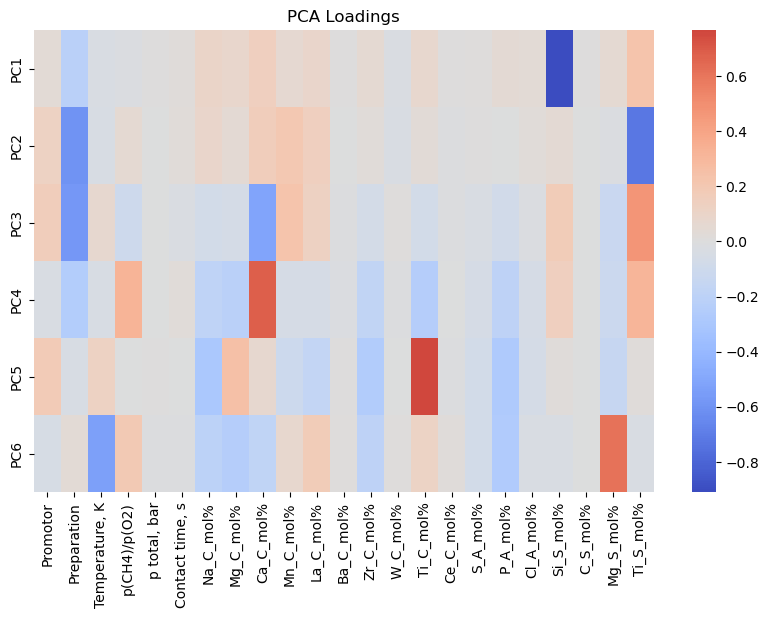

,Promotor,Preparation,"Temperature, K",p(CH4)/p(O2),"p total, bar","Contact time, s",Na_C_mol%,Mg_C_mol%,Ca_C_mol%,Mn_C_mol%,...,W_C_mol%,Ti_C_mol%,Ce_C_mol%,S_A_mol%,P_A_mol%,Cl_A_mol%,Si_S_mol%,C_S_mol%,Mg_S_mol%,Ti_S_mol%
PC1,0.038113,-0.222069,-0.037813,-0.014614,0.004340,0.017277,0.100608,0.084938,0.147889,0.063947,...,-0.023995,0.074470,0.005352,0.013536,0.041476,0.033385,-0.909675,0.001342,0.055700,0.230991
PC2,0.120120,-0.601371,-0.044045,0.049463,-0.000372,0.025759,0.088240,0.044884,0.159359,0.199396,...,-0.029235,0.031597,-0.011909,0.001200,-0.000447,0.024891,0.042614,0.000467,-0.013878,-0.720058
PC3,0.157905,-0.577211,0.071091,-0.101865,-0.000099,-0.022865,-0.075159,-0.061254,-0.511289,0.231914,...,0.013296,-0.077595,-0.010348,-0.037417,-0.082926,-0.017933,0.171149,-0.000590,-0.136189,0.466273
PC4,-0.027495,-0.252462,-0.039333,0.321712,-0.002753,0.023068,-0.187257,-0.219865,0.685829,-0.058084,...,-0.011310,-0.247025,-0.001966,-0.053217,-0.195159,-0.051861,0.148288,-0.003594,-0.121106,0.314153
PC5,0.181211,-0.041191,0.118966,-0.000004,0.001661,-0.001421,-0.288861,0.254221,0.066520,-0.110209,...,-0.000775,0.766698,-0.009593,-0.072031,-0.272856,-0.061275,0.017546,-0.002434,-0.144074,0.016526
PC6,-0.045848,0.038790,-0.530621,0.195422,-0.011166,-0.008644,-0.199730,-0.242908,-0.182369,0.075793,...,0.008248,0.113030,0.016963,-0.076051,-0.264533,-0.037579,-0.034547,-0.000823,0.613559,-0.035318


In [ ]:
components_df.index = [f"PC{i+1}" for i in range(len(components))]

# Plot the PCA loadings
plt.figure(figsize=(10, 6))
sns.heatmap(components_df, cmap='coolwarm', center=0)
plt.title("PCA Loadings")
plt.show()

components_df

In [ ]:
num_samples = 993

# 임의의 특성과 타겟 데이터 생성
X_example = pd.DataFrame({
    'Promotor': np.random.rand(num_samples),
    'Preparation': np.random.rand(num_samples),
    'Temperature, K': np.random.rand(num_samples),
    'p(CH4)/p(O2)': np.random.rand(num_samples),
    'p total, bar': np.random.rand(num_samples),
    'Contact time, s': np.random.rand(num_samples),
    'Na_C_mol%': np.random.rand(num_samples),
    'Mg_C_mol%': np.random.rand(num_samples),
    'Ca_C_mol%': np.random.rand(num_samples),
    'Mn_C_mol%': np.random.rand(num_samples),
    'La_C_mol%': np.random.rand(num_samples),
    'Ba_C_mol%': np.random.rand(num_samples),
    'Zr_C_mol%': np.random.rand(num_samples),
    'W_C_mol%': np.random.rand(num_samples),
    'Ti_C_mol%': np.random.rand(num_samples),
    'Ce_C_mol%': np.random.rand(num_samples),
    'S_A_mol%': np.random.rand(num_samples),
    'P_A_mol%': np.random.rand(num_samples),
    'Cl_A_mol%': np.random.rand(num_samples),
    'Si_S_mol%': np.random.rand(num_samples),
    'C_S_mol%': np.random.rand(num_samples),
    'Mg_S_mol%': np.random.rand(num_samples),
    'Ti_S_mol%': np.random.rand(num_samples)
})

y_example = filtered_Na[output_column]

# 선형 회귀 모델 학습
model_PCA = LinearRegression()
model.fit(X_example, y_example)

# 각 특성에 대한 회귀 계수를 데이터프레임으로 만들기
coeff_df = pd.DataFrame(model.coef_, X_example.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Promotor,-0.999930
Preparation,-0.116137
"Temperature, K",0.070162
p(CH4)/p(O2),-0.591242
"p total, bar",-0.427037
"Contact time, s",0.863590
Na_C_mol%,0.100615
Mg_C_mol%,-0.148296
Ca_C_mol%,-0.171213
Mn_C_mol%,-0.652514


In [ ]:
# 역전파를 통한 특성 중요도

with tf.GradientTape() as tape:
    tape.watch(X_test_reduced)
    predictions = model(X_test_reduced)

gradients = tape.gradient(predictions, X_test_reduced)

ValueError: Passed in object [[ 0.76320177  0.55182074  0.43272011  0.08568866  0.04316693 -0.04540616]
 [ 0.68126213  0.12968051 -0.69116001  0.64734404  0.05188071 -0.0615973 ]
 [ 0.85325914  0.6602703   0.31971546  0.04386234 -0.25607855 -0.11690701]
 ...
 [-0.32765695 -0.00368832  0.02139145  0.02772265  0.02191708 -0.06069888]
 [-0.32836292 -0.0012988   0.01647043  0.04326429  0.02191688 -0.05125819]
 [-0.25440962  0.0134903  -0.0074958   0.01657572  0.02288955  0.10633095]] of type 'ndarray', not tf.Tensor or tf.Variable or ExtensionType.

In [ ]:
def calculate_influence_function(model, X_test_reduced, y_train):
    # Assume the model has a single output unit and uses mean_squared_error loss
    predictions = model.predict(X_test_reduced).flatten()
    residuals = y_test_reduced - predictions
    
    # Calculate the gradient of the loss with respect to predictions
    gradient = -2 * residuals

    # Calculate the Hessian matrix approximation (it's diagonal for MSE loss)
    hessian_diag = np.full_like(gradient, 2)

    # Inverse of the Hessian matrix (also diagonal for MSE)
    hessian_inv_diag = 1 / hessian_diag

    # Calculate the influence function values for each training point
    influence_function = -gradient * hessian_inv_diag

    return influence_function

In [ ]:
from sklearn.ensemble import VotingRegressor
from scikeras.wrappers import KerasRegressor

# Initialize the first-level base models with the optimized hyperparameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
# Define a function to create the MLP model
def create_mlp_model():
    model = Sequential()
    model.add(Dense(best_mlp_params['hidden_units_1'], activation='relu', input_shape=(X_train_pca.shape[1],)))
    model.add(Dense(best_mlp_params['hidden_units_2'], activation='relu'))
    model.add(Dense(1, activation='relu'))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create a KerasRegressor object from the MLP model function
mlp_model = KerasRegressor(model=create_mlp_model, epochs=100, batch_size=32, verbose=0)

# Create a VotingRegressor instance
voting_reg = VotingRegressor(estimators=[
    ('lr', lr_model), 
    ('knn', knn_model), 
    ('svr', svr_model),
    ('gpr', gpr_model), 
    ('rfr', rfr_model), 
    ('xgb', xgb_model),
    ('mlp', mlp_model)
])

# Fit the ensemble model
voting_reg.fit(X_train_pca, y_train_scaled)

# Make predictions on validation set
voting_predictions = voting_reg.predict(X_test_pca)
voting_predictions = np.maximum(voting_predictions, 0)  # Set lower bound to 0
voting_predictions_train = voting_reg.predict(X_train_pca)
voting_predictions_train = np.maximum(voting_predictions_train, 0)

# Calculate the MSE
voting_rmse = np.sqrt(mean_squared_error(y_test_scaled.ravel(), voting_predictions))
voting_train_rmse = np.sqrt(mean_squared_error(y_train_scaled.ravel(), voting_predictions_train))
voting_test_r2 = r2_score(y_test_scaled.ravel(), voting_predictions)
voting_r2 = r2_score(y_train_scaled, voting_reg.predict(X_train_pca))

# Add to the validation MSE dictionary
validation_mse['VotingRegressor'] = voting_rmse

print(f"Voting Regressor RMSE: {voting_rmse}")

c:\Users\OJH\anaconda3\Lib\site-packages\sklearn\ensemble\_voting.py:604: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Voting Regressor RMSE: 0.17320149943410224


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Initialize the first-level base models with the optimized hyperparameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
# Define a function to create the MLP model
def create_mlp_model():
    model = Sequential()
    model.add(Dense(best_mlp_params['hidden_units_1'], activation='relu', input_shape=(X_train_pca.shape[1],)))
    model.add(Dense(best_mlp_params['hidden_units_2'], activation='relu'))
    model.add(Dense(1, activation='relu'))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create a KerasRegressor object from the MLP model function
mlp_model = KerasRegressor(model=create_mlp_model, epochs=100, batch_size=32, verbose=0)

# Initialize the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=[
        ('lr', lr_model),
        ('knn', knn_model),
        ('svr', svr_model),
        ('gpr', gpr_model),
        ('rfr', rfr_model),
        ('xgb', xgb_model),
        ('mlp', mlp_model)
    ],
    final_estimator=LinearRegression()
)

# Fit the ensemble model
stacking_regressor.fit(X_train_pca, y_train_scaled)

# Make predictions on the validation set
stacking_predictions = stacking_regressor.predict(X_test_pca)
stacking_predictions = np.maximum(stacking_predictions, 0)  # Set lower bound to 0
stacking_predictions_train = stacking_regressor.predict(X_train_pca)
stacking_predictions_train = np.maximum(stacking_predictions_train, 0)  # Set lower bound to 0

# Calculate the MSE
stacking_rmse = np.sqrt(mean_squared_error(y_test_scaled, stacking_predictions))
stacking_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, stacking_predictions_train))
stacking_r2 = r2_score(y_train_scaled, stacking_regressor.predict(X_train_pca))
stacking_r2_test = r2_score(y_test_scaled, stacking_predictions)

print(f"Stacking Regressor RMSE: {stacking_rmse}")

c:\Users\OJH\anaconda3\Lib\site-packages\sklearn\ensemble\_stacking.py:955: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Stacking Regressor RMSE: 0.19221285495711404


[0.20376461644861502, 0.3093423777370253, 0.20477886179410007, 0.18601038467624947, 0.1797706135171956, 0.19096286979333651, 0.17798329858303466, 0.17320149943410224, 0.19221285495711404]


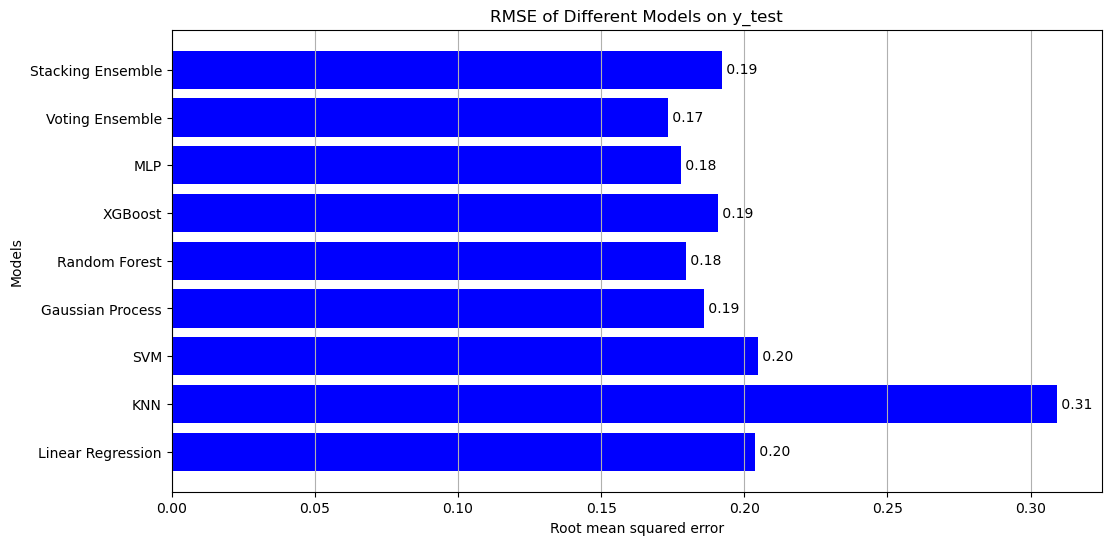

In [ ]:
print([lr_rmse, knn_rmse, svr_rmse, gpr_rmse, rfr_rmse, xgb_rmse, mlp_rmse, voting_rmse, stacking_rmse])

mse_values = [lr_rmse, knn_rmse, svr_rmse, gpr_rmse, rfr_rmse, xgb_rmse, mlp_rmse, voting_rmse, stacking_rmse]
model_names = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']


# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, mse_values, color='blue')
plt.xlabel('Root mean squared error')
plt.ylabel('Models')
plt.title('RMSE of Different Models on y_test')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(mse_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

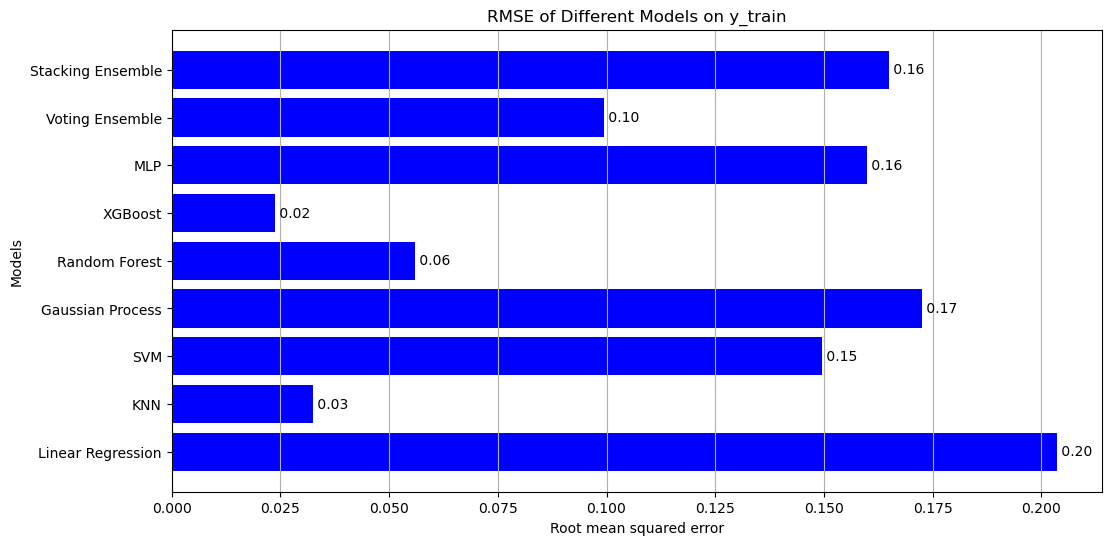

In [ ]:
rmse_train_values = [lr_rmse_train, knn_rmse_train, svr_rmse_train, gpr_rmse_train, rfr_rmse_train, xgb_rmse_train, mlp_rmse_train, voting_train_rmse, stacking_rmse_train]
model_names_train = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']

# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names_train, rmse_train_values, color='blue')
plt.xlabel('Root mean squared error')
plt.ylabel('Models')
plt.title('RMSE of Different Models on y_train')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(rmse_train_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

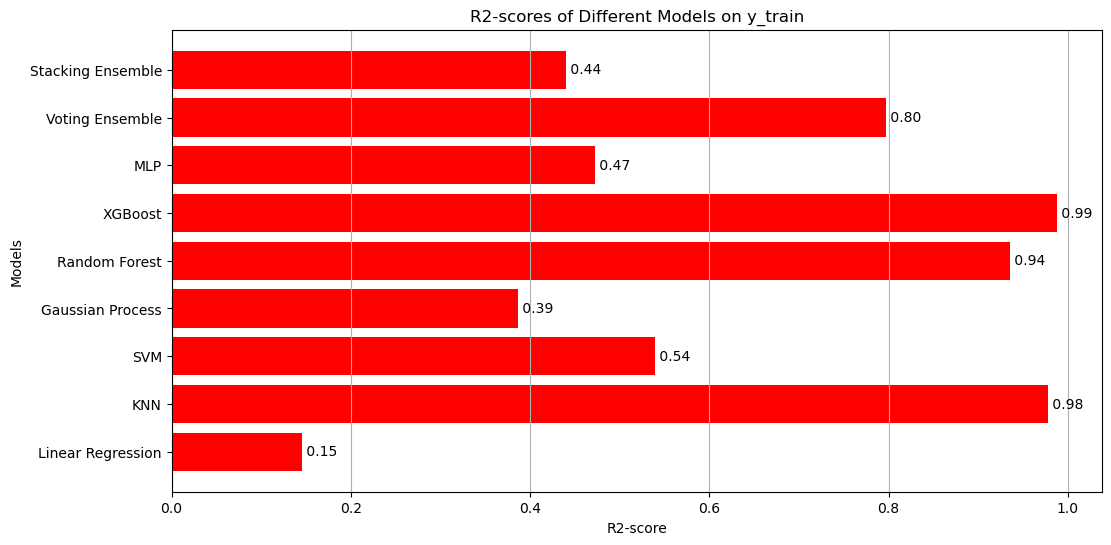

In [ ]:
r2_plus_values = [lr_r2, knn_r2, svr_r2, gpr_r2, rfr_r2, xgb_r2, mlp_r2, voting_r2, stacking_r2]
model_names_plus = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']

# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names_plus, r2_plus_values, color='red')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_train')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(r2_plus_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [ ]:
lr_predictions_original = scaler_1.inverse_transform(lr_predictions.reshape(-1, 1))
knn_predictions_original = scaler_1.inverse_transform(knn_predictions.reshape(-1, 1))
svr_predictions_original = scaler_1.inverse_transform(svr_predictions.reshape(-1, 1))
gpr_predictions_original = scaler_1.inverse_transform(gpr_predictions.reshape(-1, 1))
rfr_predictions_original = scaler_1.inverse_transform(rfr_predictions.reshape(-1, 1))
xgb_predictions_original = scaler_1.inverse_transform(xgb_predictions.reshape(-1, 1))
mlp_predictions_original = scaler_1.inverse_transform(mlp_predictions.reshape(-1, 1))
voting_predictions_original = scaler_1.inverse_transform(voting_predictions.reshape(-1, 1))
stacking_predictions_original = scaler_1.inverse_transform(stacking_predictions.reshape(-1, 1))

results_df = pd.DataFrame({
    'y_test_original': y_test.ravel(),
    'lr_predictions_original': lr_predictions_original.ravel(),
    'knn_predictions_original': knn_predictions_original.ravel(),
    'svr_predictions_original': svr_predictions_original.ravel(),
    'gpr_predictions_original': gpr_predictions_original.ravel(),
    'rfr_predictions_original': rfr_predictions_original.ravel(),
    'xgb_predictions_original': xgb_predictions_original.ravel(),
    'mlp_predictions_original': mlp_predictions_original.ravel(),
    'voting_predictions_original': voting_predictions_original.ravel(),
    'stacking_predictions_original': stacking_predictions_original.ravel()
})

results_df.to_csv('model_predictions.csv', index=False)

results_df

,y_test_original,lr_predictions_original,knn_predictions_original,svr_predictions_original,gpr_predictions_original,rfr_predictions_original,xgb_predictions_original,mlp_predictions_original,voting_predictions_original,stacking_predictions_original
0,15.1,13.485782,0.7,7.269807,11.233607,11.961583,11.637267,9.153127,10.004642,15.864570
1,12.5,8.360664,13.3,12.166542,11.940427,12.224500,12.978956,10.627818,12.001474,13.488230
2,0.6,11.786727,0.7,0.000300,10.713359,13.543000,9.675733,5.344486,6.675166,12.514322
3,13.8,6.371135,19.2,13.034511,13.119277,6.658500,9.208231,17.348600,12.155711,11.861220
4,2.8,16.671787,15.6,13.203428,11.357091,12.628000,15.568666,10.831948,14.414664,13.445791
...,...,...,...,...,...,...,...,...,...,...
288,18.7,13.696839,18.7,17.390096,16.307134,19.159000,18.901630,15.774942,17.492958,16.909557
289,16.7,13.911813,16.7,18.674929,16.939078,16.513500,16.549145,15.941511,16.618615,16.272424
290,13.6,13.623279,13.6,15.311782,15.782706,13.604286,14.495454,14.708335,14.535562,15.352497
291,14.0,13.459105,14.0,13.093957,14.965985,13.582571,12.844437,13.502547,13.662967,14.473736


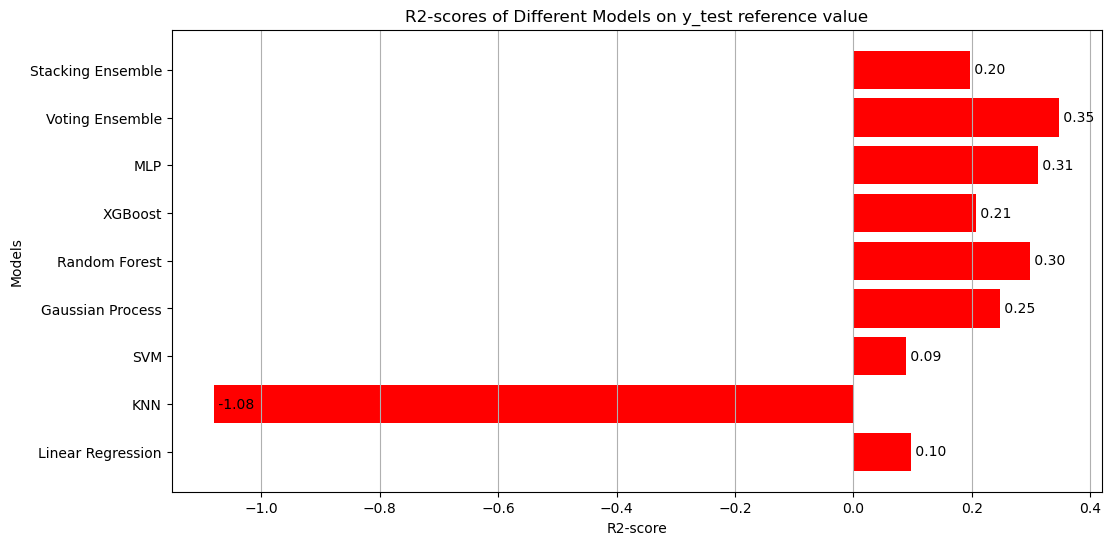

In [ ]:
lr_original_r2 = r2_score(y_test, lr_predictions_original)
knn_original_r2 = r2_score(y_test, knn_predictions_original)
svr_original_r2 = r2_score(y_test, svr_predictions_original)
gpr_original_r2 = r2_score(y_test, gpr_predictions_original)
rfr_original_r2 = r2_score(y_test, rfr_predictions_original)
xgb_original_r2 = r2_score(y_test, xgb_predictions_original)
mlp_original_r2 = r2_score(y_test, mlp_predictions_original)
voting_original_r2 = r2_score(y_test, voting_predictions_original)
stacking_original_r2 = r2_score(y_test, stacking_predictions_original)

r2_original_values = [lr_original_r2, knn_original_r2, svr_original_r2, gpr_original_r2, rfr_original_r2, xgb_original_r2, mlp_original_r2, voting_original_r2, stacking_original_r2]
model_names_9 = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']

# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names_9, r2_original_values, color='red')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_test reference value')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(r2_original_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [ ]:
# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original = lr_predictions_original.flatten()
xgb_predictions_original = xgb_predictions_original.flatten()

# Check the lengths
print(len(y_test), len(lr_predictions_original))

# Check the shapes if they are NumPy arrays
print(np.shape(y_test), np.shape(lr_predictions_original))

# If they are pandas Series, convert to NumPy arrays
if isinstance(y_test, pd.Series):
    y_test = y_test.values
if isinstance(lr_predictions_original, pd.Series):
    lr_predictions_original = lr_predictions_original.values

# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original = lr_predictions_original.flatten()

AttributeError: 'Series' object has no attribute 'flatten'

In [ ]:
lr_predictions_original_train = scaler_1.inverse_transform(lr_predictions_train.reshape(-1, 1))
knn_predictions_original_train = scaler_1.inverse_transform(knn_predictions_train.reshape(-1, 1))
svr_predictions_original_train = scaler_1.inverse_transform(svr_predictions_train.reshape(-1, 1))
gpr_predictions_original_train = scaler_1.inverse_transform(gpr_predictions_train.reshape(-1, 1))
rfr_predictions_original_train = scaler_1.inverse_transform(rfr_predictions_train.reshape(-1, 1))
xgb_predictions_original_train = scaler_1.inverse_transform(xgb_predictions_train.reshape(-1, 1))
mlp_predictions_original_train = scaler_1.inverse_transform(mlp_predictions_train.reshape(-1, 1))
voting_predictions_original_train = scaler_1.inverse_transform(voting_predictions_train.reshape(-1, 1))
stacking_predictions_original_train = scaler_1.inverse_transform(stacking_predictions_train.reshape(-1, 1))

# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original_train = lr_predictions_original_train.flatten()
svr_predictions_original_train = svr_predictions_original_train.flatten()
gpr_predictions_original_train = gpr_predictions_original_train.flatten()
rfr_predictions_original_train = rfr_predictions_original_train.flatten()
xgb_predictions_original_train = xgb_predictions_original_train.flatten()
mlp_predictions_original_train = mlp_predictions_original_train.flatten()
voting_predictions_original_train = voting_predictions_original_train.flatten()
stacking_predictions_original_train = stacking_predictions_original_train.flatten()

def plot_scatter(y_true, y_pred, model_name):
    plt.scatter(y_true, y_pred, label='Data points')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    
    # y=x 라인 추가
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x line')
    
    plt.axis('equal')
    plt.axis('square')
    plt.title(f'Scatter plot for {model_name}_train')
    plt.legend()
    plt.show()

# 각 모델에 대한 산점도 그리기
plot_scatter(y_train, lr_predictions_original_train, 'Linear Regression')
plot_scatter(y_train, knn_predictions_original_train, 'KNN')
plot_scatter(y_train, svr_predictions_original_train, 'SVR')
plot_scatter(y_train, gpr_predictions_original_train, 'GPR')
plot_scatter(y_train, rfr_predictions_original_train, 'RFR')
plot_scatter(y_train, xgb_predictions_original_train, 'XGB')
plot_scatter(y_train, mlp_predictions_original_train, 'MLP')
plot_scatter(y_train, voting_predictions_original_train, 'Voting Regressor')
plot_scatter(y_train, stacking_predictions_original_train, 'Stacking Regressor')

In [ ]:
def plot_scatter(y_true, y_pred, model_name):
    plt.scatter(y_true, y_pred, label='Data points')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    
    # y=x 라인 추가
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x line')
    
    plt.axis('equal')
    plt.axis('square')
    plt.title(f'Scatter plot for {model_name}')
    plt.legend()
    plt.show()

# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original = lr_predictions_original.flatten()
svr_predictions_original = svr_predictions_original.flatten()
gpr_predictions_original = gpr_predictions_original.flatten()
rfr_predictions_original = rfr_predictions_original.flatten()
xgb_predictions_original = xgb_predictions_original.flatten()
mlp_predictions_original = mlp_predictions_original.flatten()
voting_predictions_original = voting_predictions_original.flatten()
stacking_predictions_original = stacking_predictions_original.flatten()

# 각 모델에 대한 산점도 그리기
plot_scatter(y_test, lr_predictions_original, 'Linear Regression')
plot_scatter(y_test, knn_predictions_original, 'KNN')
plot_scatter(y_test, svr_predictions_original, 'SVR')
plot_scatter(y_test, gpr_predictions_original, 'GPR')
plot_scatter(y_test, rfr_predictions_original, 'RFR')
plot_scatter(y_test, xgb_predictions_original, 'XGB')
plot_scatter(y_test, mlp_predictions_original, 'MLP')
plot_scatter(y_test, voting_predictions_original, 'Voting Regressor')
plot_scatter(y_test, stacking_predictions_original, 'Stacking Regressor')

In [ ]:
def plot_scatter_with_x_axis(x_values, y_true, y_pred, model_name):
    plt.scatter(x_values, y_true, label='True Values', alpha=0.5)
    plt.scatter(x_values, y_pred, label='Predictions', alpha=0.5)
    plt.xlabel('Na_C_mol%')
    plt.ylabel('Output Values')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.legend()
    plt.show()

na_c_mol_percent_values = test_data['Na_C_mol%'].values

plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, lr_predictions_original, 'Linear Regression')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, knn_predictions_original, 'KNN')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, svr_predictions_original, 'SVR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, gpr_predictions_original, 'GPR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, rfr_predictions_original, 'RFR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, xgb_predictions_original, 'XGB')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, mlp_predictions_original, 'MLP')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, voting_predictions_original, 'Voting Regressor')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, stacking_predictions_original, 'Stacking Regressor')

In [ ]:
def plot_scatter_with_x_axis(x_values, y_true, y_pred, model_name):
    plt.scatter(x_values, y_true, label='True Values', alpha=0.5)
    plt.scatter(x_values, y_pred, label='Predictions', alpha=0.5)
    plt.xlabel('Na_C_mol%')
    plt.ylabel('Output Values')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.legend()
    plt.show()

na_c_mol_percent_values = train_data['Na_C_mol%'].values

plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, lr_predictions_original_train, 'Linear Regression')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, knn_predictions_original_train, 'KNN')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, svr_predictions_original_train, 'SVR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, gpr_predictions_original_train, 'GPR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, rfr_predictions_original_train, 'RFR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, xgb_predictions_original_train, 'XGB')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, mlp_predictions_original_train, 'MLP')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, voting_predictions_original_train, 'Voting Regressor')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, stacking_predictions_original_train, 'Stacking Regressor')

In [ ]:
# Create a scatter plot
plt.figure(figsize=(12, 8))

# Plot the true values
plt.scatter(na_c_mol_percent_values, y_test, label='True Values', color='black', alpha=0.7)

# Plot the predictions from different models
# plt.scatter(na_c_mol_percent_values, lr_predictions_original, label='LR Predictions', color='blue', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, knn_predictions_original, label='KNN Predictions', color='green', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, svr_predictions_original, label='SVR Predictions', color='red', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, gpr_predictions_original, label='GPR Predictions', color='orange', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, rfr_predictions_original, label='RFR Predictions', color='purple', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, xgb_predictions_original, label='XGB Predictions', color='brown', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, mlp_predictions_original, label='MLP Predictions', color='pink', alpha=0.7)
plt.scatter(na_c_mol_percent_values, voting_predictions_original, label='Voting Predictions', color='red', alpha=0.7)
plt.scatter(na_c_mol_percent_values, stacking_predictions_original, label='Stacking Predictions', color='blue', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Na_C_mol%')
plt.ylabel('Y(C2), %')
plt.title('True vs Predicted Values by Different Models')
plt.legend()

plt.show()

In [ ]:
def plot_scatter_with_x_axis(x_values, y_true, y_pred, model_name):
    plt.scatter(x_values, y_true, label='True Values', alpha=0.5)
    plt.scatter(x_values, y_pred, label='Predictions', alpha=0.5)
    plt.xlabel('Feed ratio')
    plt.ylabel('Output Values')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.legend()
    plt.show()

na_c_mol_percent_values = test_data['p(CH4)/p(O2)'].values

# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, lr_predictions_original, 'Linear Regression')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, knn_predictions_original, 'KNN')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, svr_predictions_original, 'SVR')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, gpr_predictions_original, 'GPR')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, rfr_predictions_original, 'RFR')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, xgb_predictions_original, 'XGB')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, mlp_predictions_original, 'MLP')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, voting_predictions_original, 'Voting Regressor')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, stacking_predictions_original, 'Stacking Regressor')



In [ ]:
# 예측값을 1차원 배열로 변환
voting_predictions_flatten = voting_predictions_original.flatten()

# 첫 번째 주성분만 추출
X_test_pca_first_component = X_test_pca[:, 0]

# 형태가 동일한지 확인
if X_test_pca_first_component.shape == y_test.shape == voting_predictions_flatten.shape:
    plt.scatter(X_test_pca_first_component, y_test, label='Actual Values', color='red')
    plt.scatter(X_test_pca_first_component, voting_predictions_flatten, label='Voting Ensemble Predictions', color='blue')
    plt.xlabel('PCA Component 1')
    plt.ylabel('Output Variable')
    plt.title('Actual vs Predicted Values by PCA Component')
    plt.legend()
    plt.show()
else:
    print("Shapes are not matching!")

In [ ]:
# 첫 번째 주성분만 추출
X_test_pca_first_component = X_test_pca[:, 1]

# 형태가 동일한지 확인
if X_test_pca_first_component.shape == y_test.shape == voting_predictions_flatten.shape:
    plt.scatter(X_test_pca_first_component, y_test, label='Actual Values', color='red')
    plt.scatter(X_test_pca_first_component, voting_predictions_flatten, label='Voting Ensemble Predictions', color='blue')
    plt.xlabel('PCA Component 2')
    plt.ylabel('Output Variable')
    plt.title('Actual vs Predicted Values by PCA Component_2')
    plt.legend()
    plt.show()
else:
    print("Shapes are not matching!")

In [ ]:
# Create DataFrame for easy plotting
df_train = pd.DataFrame({'Promotor': X_train['Promotor'], 'Dataset': 'Train'})
df_test = pd.DataFrame({'Promotor': X_test['Promotor'], 'Dataset': 'Test'})
df = pd.concat([df_train, df_test])

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Promotor', hue='Dataset')
plt.title('Distribution of "Promotor" in Train and Test Sets')
plt.show()

In [ ]:
from patsy import dmatrix

print(X_train[col].describe())
print(X_test[col].describe())

print(len(np.unique(X_train[col])))
print(len(np.unique(X_test[col])))

# Initialize an empty array for ensemble predictions
ensemble_predictions = np.zeros(len(y_test))

# Number of ensemble models
n_models = 1000

# Loop through each feature and fit a MARS model
for col in input_columns:
    # Create design matrices for the train and test sets for the current feature
    design_matrix_train = dmatrix("cr(x, df=3)", {"x": X_train[col]})
    design_matrix_test = dmatrix("cr(x, df=3)", {"x": X_test[col]})
    
    # Initialize temporary predictions for the ensemble
    temp_predictions = np.zeros(len(y_test))
    
    # Fit n_models number of MARS models and accumulate their predictions
    for _ in range(n_models):
        model = LinearRegression()
        model.fit(design_matrix_train, y_train)
        predictions = model.predict(design_matrix_test)
        temp_predictions += predictions

    # Average the predictions for the current feature
    temp_predictions /= n_models
    
    # Add the averaged predictions to the ensemble predictions
    ensemble_predictions += temp_predictions

# Average the ensemble predictions across all features
ensemble_predictions /= len(input_columns)

# Calculate the ensemble MSE
ensemble_mse = mean_squared_error(y_test, ensemble_predictions)

print(f"Ensemble MARS MSE: {ensemble_mse}")

In [ ]:
import pymc as pm
import aesara.tensor as at
import aesara

with pm.Model() as model_0:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", 10)

    mu = alpha + beta * X_train_pca

    